# Real Estate Sales Analysis – 2025


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [79]:
df = pd.read_csv("real_estate_sales_2025.csv")
df.head()

,date,city,property_type,units_sold,price_per_unit_lakhs,total_sales_value_lakhs
0,13-04-2025,Delhi,Villa,4,208.86,835.44
1,15-12-2025,Mumbai,Apartment,1,187.99,187.99
2,28-09-2025,Chennai,Villa,5,240.22,1201.10
3,17-04-2025,Bengaluru,Commercial,9,34.01,306.09
4,13-03-2025,Chennai,Villa,8,73.07,584.56


In [11]:
df.shape

(500, 6)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     500 non-null    object 
 1   city                     500 non-null    object 
 2   property_type            500 non-null    object 
 3   units_sold               500 non-null    int64  
 4   price_per_unit_lakhs     500 non-null    float64
 5   total_sales_value_lakhs  500 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 23.6+ KB


In [13]:
df.describe()

,units_sold,price_per_unit_lakhs,total_sales_value_lakhs
count,500.000000,500.000000,500.000000
mean,4.972000,139.156600,687.374540
std,2.659579,63.425845,510.110746
min,1.000000,30.710000,32.670000
25%,3.000000,83.032500,283.685000
50%,5.000000,141.320000,523.800000
75%,7.000000,192.702500,1002.000000
max,9.000000,249.640000,2232.720000


In [20]:
## Convert to date

df.columns


Index(['date', 'city', 'property_type', 'units_sold', 'price_per_unit_lakhs',
       'total_sales_value_lakhs'],
      dtype='object')

In [32]:
df['date'] = pd.to_datetime(df['date'])

In [27]:
df.isnull().sum()

date                       0
city                       0
property_type              0
units_sold                 0
price_per_unit_lakhs       0
total_sales_value_lakhs    0
dtype: int64

In [94]:
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

In [95]:
df['date'].dtype

dtype('<M8[ns]')

In [90]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [42]:
## Business Metrics

tot_sales = df['total_sales_value_lakhs'].sum()
tot_units = df['units_sold'].sum()
avg_price = df['price_per_unit_lakhs'].mean()

print("Total Sales:",tot_sales)

print("total units Sold:",tot_units)
print("Average Price per unit:",avg_price) 

Total Sales: 343687.26999999996
total units Sold: 2486
Average Price per unit: 139.1566


In [48]:
#city wise Analysis

city_sales = df.groupby('city').agg({
    'units_sold' : 'sum',
    'total_sales_value_lakhs': 'sum'
}).sort_values(by='total_sales_value_lakhs', ascending = False)

city_sales


,units_sold,total_sales_value_lakhs
city,,
Mumbai,536,75503.29
Hyderabad,548,74435.40
Chennai,430,65603.74
Bengaluru,485,64367.81
Delhi,487,63777.03


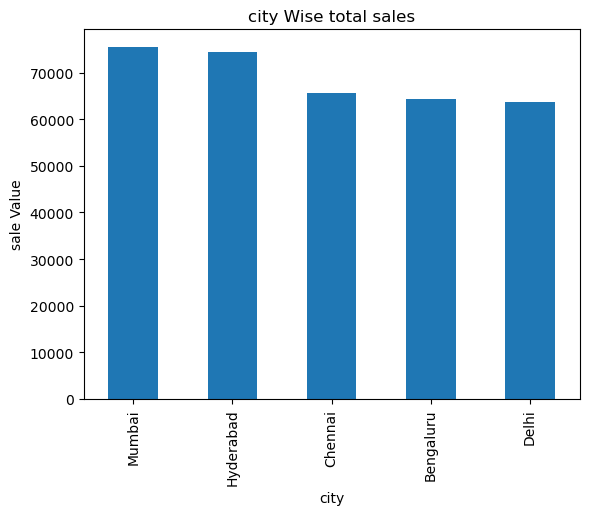

In [70]:
#city_sales

city_sales['total_sales_value_lakhs'].plot(kind='bar')
plt.title("city Wise total sales")
plt.ylabel("sale Value")
plt.show()

In [73]:
#propert_type_sales

propert_type_sales = df.groupby('property_type').agg({
    'units_sold':'sum',
    'total_sales_value_lakhs':'sum',
    'price_per_unit_lakhs': 'mean'}).sort_values(by='total_sales_value_lakhs',ascending=False)

propert_type_sales
                                                     


    

,units_sold,total_sales_value_lakhs,price_per_unit_lakhs
property_type,,,
Apartment,821,118280.63,145.393025
Commercial,865,117002.28,136.378977
Villa,800,108404.36,135.937840


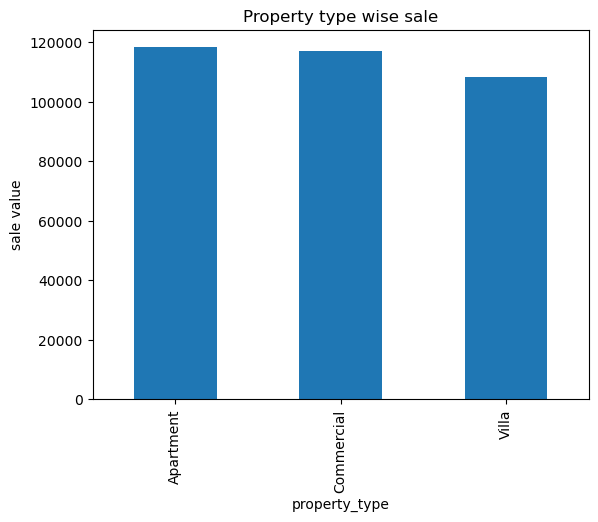

In [78]:
##propert_type_sales

propert_type_sales['total_sales_value_lakhs'].plot(kind='bar')
plt.title('Property type wise sale')
plt.ylabel('sale value')
plt.show()


In [98]:
##Monthly sales trend

monthly_sales = df.groupby('month')['total_sales_value_lakhs'].sum()
monthly_sales

month
1     21539.45
2     31592.34
3     16606.87
4     36140.71
5     33221.66
6     32545.88
7     28543.39
8     34544.46
9     31131.84
10    27231.65
11    21977.15
12    28611.87
Name: total_sales_value_lakhs, dtype: float64

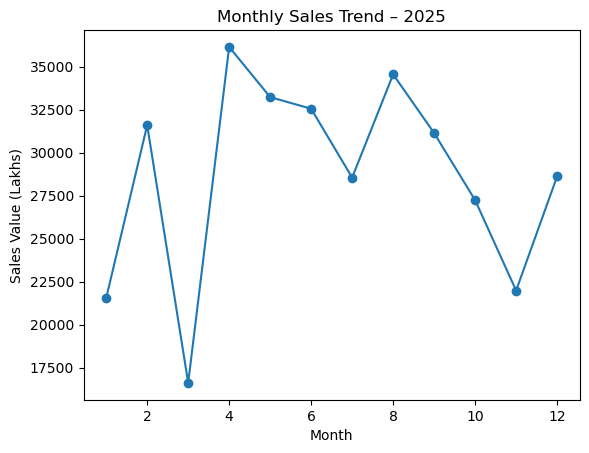

In [103]:
##monthly_sales visaul

monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend – 2025")
plt.xlabel("Month")
plt.ylabel("Sales Value (Lakhs)")
plt.show()


In [104]:
## Pivoted

pivot = pd.pivot_table(
    df,
    values='total_sales_value_lakhs',
    index='city',
    columns='property_type',
    aggfunc='sum'
)

pivot


property_type,Apartment,Commercial,Villa
city,,,
Bengaluru,19421.44,21769.21,23177.16
Chennai,17055.36,25611.92,22936.46
Delhi,23893.12,19971.84,19912.07
Hyderabad,26406.70,25111.80,22916.90
Mumbai,31504.01,24537.51,19461.77


In [108]:
plt.savefig("visuals/monthly_sales_trend.png")


<Figure size 640x480 with 0 Axes>